In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

In [12]:
def self_avoid(n, trials, rng=None):

  dead_ends = 0

  for t in range(trials):
    a = [[False for j in range(n)] for i in range(n)]
    x = n // 2
    y = n // 2

    while (x > 0) and (x < n-1) and (y > 0) and (y < n-1):
      # Check for dead end and make a random move
      a[x][y] = True
      if a[x-1][y] and a[x+1][y] and a[x][y-1] and a[x][y+1]:
        dead_ends += 1
        break

      r = rng.integers(1, 5)
      if (r == 1) and (not a[x+1][y]): x += 1
      elif (r == 2) and (not a[x-1][y]): x -= 1
      elif (r == 3) and (not a[x][y+1]): y += 1
      elif (r == 4) and (not a[x][y-1]): y -= 1
  
  print(f"({n:3d}, {trials:5d}): {100*dead_ends//trials:2d}% dead ends")

In [13]:
seed = 260306
rng = np.random.default_rng(seed)

n_and_trials_arr = [
  [5, 100], [20, 100], [40, 100], [80, 100],
  [5, 1000], [20, 1000], [40, 1000], [80, 1000]]

for n, trials in n_and_trials_arr:
  self_avoid(n, trials, rng=rng)

(  5,   100):  0% dead ends
( 20,   100): 29% dead ends
( 40,   100): 74% dead ends
( 80,   100): 99% dead ends
(  5,  1000):  0% dead ends
( 20,  1000): 32% dead ends
( 40,  1000): 76% dead ends
( 80,  1000): 98% dead ends


Self-avoiding random walks in a 21-by-21 brid

In [14]:
def self_avoid_illustrate():
  return

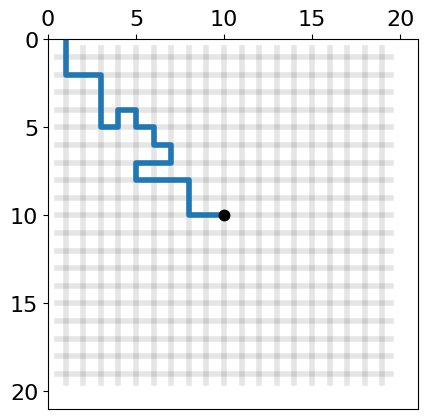

In [82]:
n = 21
# seed = 260306
seed = None
rng = np.random.default_rng(seed)

dead_ends = 0
a = [[False for j in range(n)] for i in range(n)]

x = n // 2
y = n // 2
paths = [[x, y]]

while (x > 0) and (x < n-1) and (y > 0) and (y < n-1):
  # Check for dead end and make a random move
  a[x][y] = True
  if a[x-1][y] and a[x+1][y] and a[x][y-1] and a[x][y+1]:
    dead_ends += 1
    break

  r = rng.integers(1, 5)
  if (r == 1) and (not a[x+1][y]): x += 1
  elif (r == 2) and (not a[x-1][y]): x -= 1
  elif (r == 3) and (not a[x][y+1]): y += 1
  elif (r == 4) and (not a[x][y-1]): y -= 1

  paths.append([x, y])


fig, ax = plt.subplots()

x_data = [paths[i][0] for i in range(len(paths))]
y_data = [paths[i][1] for i in range(len(paths))]

ax.plot(x_data[0], y_data[0], marker=".", color="k", markersize=15)
ax.plot(y_data, x_data, linewidth=4, zorder=1)

ax.set_xlim([0, n])
ax.set_ylim([0, n])
ax.set_aspect("equal")
ax.invert_yaxis()
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# -- draw grids 
for i in range(1, n-1):
  ax.plot([0.5, n-1-0.5], [i, i], color="k", linewidth=4, alpha=0.1, zorder=0)
  ax.plot([i, i], [0.5, n-1-0.5], color="k", linewidth=4, alpha=0.1, zorder=0)


# for row in a:
#   print([1 if a_ij else 0 for a_ij in row])

plt.show(fig)